In [3]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import geocat.viz as gv

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, axs = plt.subplots(2, 2, figsize=(12,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
ax = axs.flat

var = '2t'
region = "Global Ocean"

indx = 0
for label, val in months.items():
    # AUR_F
    ds_aur1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora/stats/stat_surface.nc')
    ds_aur1 = ds_aur1.sel(variable=var, region=region, rollout_step=0)
    aur1_rmse = ds_aur1['rmse_wgt_mean']
    aur1_acc = ds_aur1['acc_lat_mean']
    # AUR_R
    ds_aur2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r2/stats/stat_surface.nc')
    ds_aur2 = ds_aur2.sel(variable=var, region=region)
    aur2_rmse = ds_aur2['rmse_wgt_mean']
    aur2_acc = ds_aur2['acc_lat_mean']
    # AUR_RE
    ds_aur3 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r3/stats/stat_surface.nc')
    ds_aur3 = ds_aur3.sel(variable=var, region=region)
    aur3_rmse = ds_aur3['rmse_wgt_mean']
    aur3_acc = ds_aur3['acc_lat_mean']
    # AUR_M
    ds_aur4 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_two_way_r4/stats/stat_surface.nc')
    ds_aur4 = ds_aur4.sel(variable=var, region=region)
    aur4_rmse = ds_aur4['rmse_wgt_mean']
    aur4_acc = ds_aur4['acc_lat_mean']

    # Get data for x axis
    x = ds_aur2.coords['time']#.values
    diff = (x - x[0])/21600000000000
    diff = diff.astype(int)
    diff_day = (x - x[0])/86400000000000
    diff_day = diff_day.astype(int)

    # Calculate relative metrics
    aur3_rmse_relative = (aur3_rmse-aur2_rmse)/aur2_rmse*100.0
    aur3_acc_relative = (aur3_acc-aur2_acc)/(1.0-aur2_acc)*100.0
    aur4_rmse_relative = (aur4_rmse-aur2_rmse)/aur2_rmse*100.0
    aur4_acc_relative = (aur4_acc-aur2_acc)/(1.0-aur2_acc)*100.0

    # Plot RMSE
    ax[indx].plot(diff, aur3_rmse_relative, color='tab:red', linestyle='-', label='AUR_RE')
    ax[indx].plot(diff, aur4_rmse_relative, color='tab:red', linestyle='-.', label='AUR_RM')
    ax[indx].axhline(y=0, color='black', linestyle='-')

    # Plot ACC
    ax2 = ax[indx].twinx()
    ax2.plot(diff, aur3_acc_relative, color='tab:blue', linestyle='-', label='AUR_RE')
    ax2.plot(diff, aur4_acc_relative, color='tab:blue', linestyle='-.', label='AUR_RM')

    # Add x label
    ax[indx].set_xlim(-0.1, 35)
    if indx in [2,3]:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels(diff_day[0::7].values)
        ax[indx].set_xlabel('Lead Time [days]', fontweight='bold')
    else:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels([])

    # Add y label
    ax[indx].set_ylim(-50, 50)
    ax2.set_ylim(-50, 50)
    if indx in [1,3]:
        ax[indx].set_yticks([])
        ax[indx].set_yticklabels([])
        ax2.set_ylabel(f'Relative ACC [%]', color='tab:blue', fontweight='bold')
    if indx in [0,2]:
        ax2.set_yticks([])
        ax2.set_yticklabels([])
        ax[indx].set_ylabel(f'Relative RMSE [%]', color='tab:red', fontweight='bold')

    # Add legend
    if indx == 0:
        ax[indx].legend(ncol=2, fontsize=8, loc='upper center')

    # Add title
    ax[indx].text(1.0, 0.95, f"{label}", transform=ax[indx].transAxes, ha='right', va='center', fontweight='bold', color='green', fontsize=10)

    indx=indx+1

fig.savefig(f"Fig_2t_comp.png", dpi=300, bbox_inches='tight')

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

fig, axs = plt.subplots(2, 2, figsize=(12,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
ax = axs.flat

var = 'msl'
region = "Tropics"

indx = 0
for label, val in months.items():
    # AUR_F
    ds_aur1 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora/stats/stat_surface.nc')
    ds_aur1 = ds_aur1.sel(variable=var, region=region, rollout_step=0)
    aur1_rmse = ds_aur1['rmse_wgt_mean']
    aur1_acc = ds_aur1['acc_lat_mean']
    # AUR_R
    ds_aur2 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r2/stats/stat_surface.nc')
    ds_aur2 = ds_aur2.sel(variable=var, region=region)
    aur2_rmse = ds_aur2['rmse_wgt_mean']
    aur2_acc = ds_aur2['acc_lat_mean']
    # AUR_RE
    ds_aur3 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_r3/stats/stat_surface.nc')
    ds_aur3 = ds_aur3.sel(variable=var, region=region)
    aur3_rmse = ds_aur3['rmse_wgt_mean']
    aur3_acc = ds_aur3['acc_lat_mean']
    # AUR_M
    ds_aur4 = xr.open_dataset(f'/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/2021{val:02}01_aurora_two_way_r4/stats/stat_surface.nc')
    ds_aur4 = ds_aur4.sel(variable=var, region=region)
    aur4_rmse = ds_aur4['rmse_wgt_mean']
    aur4_acc = ds_aur4['acc_lat_mean']

    # Get data for x axis
    x = ds_aur2.coords['time']#.values
    diff = (x - x[0])/21600000000000
    diff = diff.astype(int)
    diff_day = (x - x[0])/86400000000000
    diff_day = diff_day.astype(int)

    # Calculate relative metrics
    aur3_rmse_relative = (aur3_rmse-aur2_rmse)/aur2_rmse*100.0
    aur3_acc_relative = (aur3_acc-aur2_acc)/(1.0-aur2_acc)*100.0
    aur4_rmse_relative = (aur4_rmse-aur2_rmse)/aur2_rmse*100.0
    aur4_acc_relative = (aur4_acc-aur2_acc)/(1.0-aur2_acc)*100.0

    # Plot RMSE
    ax[indx].plot(diff, aur3_rmse_relative, color='tab:red', linestyle='-', label='AUR_RE')
    ax[indx].plot(diff, aur4_rmse_relative, color='tab:red', linestyle='-.', label='AUR_RM')
    ax[indx].axhline(y=0, color='black', linestyle='-')

    # Plot ACC
    ax2 = ax[indx].twinx()
    ax2.plot(diff, aur3_acc_relative, color='tab:blue', linestyle='-', label='AUR_RE')
    ax2.plot(diff, aur4_acc_relative, color='tab:blue', linestyle='-.', label='AUR_RM')

    # Add x label
    ax[indx].set_xlim(-0.1, 35)
    if indx in [2,3]:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels(diff_day[0::7].values)
        ax[indx].set_xlabel('Lead Time [days]', fontweight='bold')
    else:
        ax[indx].set_xticks(diff[0::7].values)
        ax[indx].set_xticklabels([])

    # Add y label
    ax[indx].set_ylim(-50, 50)
    ax2.set_ylim(-50, 50)
    if indx in [1,3]:
        ax[indx].set_yticks([])
        ax[indx].set_yticklabels([])
        ax2.set_ylabel(f'ACC', color='tab:blue', fontweight='bold')
    if indx in [0,2]:
        ax2.set_yticks([])
        ax2.set_yticklabels([])
        ax[indx].set_ylabel(f'RMSE', color='tab:red', fontweight='bold')

    # Add legend
    if indx == 0:
        ax[indx].legend(ncol=2, fontsize=8, loc='upper left')
    
    # Add title
    ax[indx].text(1.0, 0.95, f"{label}", transform=ax[indx].transAxes, ha='right', va='center', fontweight='bold', color='green', fontsize=10)

    indx=indx+1

#cbar_ax = fig.add_axes([0.13, 0.16, 0.76, 0.01])
#fig.colorbar(ax[0].images[0], cax=cbar_ax, orientation='horizontal', label='Relative ACC [%]')
#fig.savefig(f"Fig_relative_ACC.png", dpi=300, bbox_inches='tight')

In [ ]:
ds = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_r2/stats/stat_surface_2d.nc')
ds = ds.isel(rollout_step=0)
ds_avg = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/20210101_aurora_r2/stats/stat_surface_2d_tmean.nc')
ds_avg = ds_avg.isel(rollout_step=0, time=0).drop_vars("time_bnds")
print(ds)
print(ds_avg)

In [ ]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

run_list = {
    "AUR_R": "r2",
    "AUR_RE": "r3",
    "AUR_RM": "two_way_r4"
}

var_list = ["2t", "2dt", "2q", 
            "2rh", "10u", "10v", 
            "10w", "msl", "sst", 
            "tcc", "tp", "swnet", 
            "lwnet", "lwdn", "swdn"]

istep = 4*7 # weekly
df = pd.DataFrame()
for mlabel, val in months.items():
    iweek = 0
    ds = xr.open_dataset(
        os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d.nc")
    ).isel(rollout_step=0)
    for idx in np.arange(0, ds.time.shape[0]-1, istep):
        istr = idx
        iend = idx+istep-1
        print(slice(istr, iend))

        # Loop over datasets
        for dlabel, prefix in run_list.items():
            print(mlabel, dlabel)

            # Load datasets
            ds = xr.open_dataset(
                os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d.nc")
            ).isel(rollout_step=0, time=slice(istr, iend))
            ds_avg = ds.mean("time")
            #ds_avg = xr.open_dataset(
            #    os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d_tmean.nc")
            #).isel(rollout_step=0, time=0).drop_vars("time_bnds")

            # Loop over variables
            for var in var_list:
                print(var)
                # Prepare data
                mod = ds[f'PRED_{var}']
                ref = ds[f'TARGET_{var}']
                valid = ref.notnull() & mod.notnull()
                mod = mod.where(valid)
                ref = ref.where(valid)

                # Calculate weights
                w = np.cos(np.deg2rad(ds['latitude']))
                w = w / w.mean('latitude')
                w = w.broadcast_like(ref)
                w = w.where(valid)

                # Calculate statistics
                std_ref = ref.weighted(w).std(dim=("latitude", "longitude"))
                std_mod = mod.weighted(w).std(dim=("latitude", "longitude"))
                std_mod_normalized = std_mod/std_ref
                std_mod_normalized = std_mod_normalized.median("time")
                corr = xr.corr(ref, mod, dim=("latitude", "longitude"), weights=w).median("time")
                mean_ref = ref.weighted(w).mean(dim=("latitude", "longitude"))
                mean_mod = mod.weighted(w).mean(dim=("latitude", "longitude"))
                crmsd = ((ref-mean_ref)-(mod-mean_mod))**2
                crmsd = crmsd.weighted(w).mean(dim=("latitude", "longitude"))**0.5
                crmsd_normalized = crmsd/std_ref
                crmsd_normalized = crmsd_normalized.median("time")

                # Add results to dataframe
                df_local = pd.DataFrame(
                    {
                        "month": val,
                        "week": iweek,
                        "model": dlabel,
                        "variable": var,
                        #"std_ref": std_ref.values,
                        #"std_mod": std_mod.values,
                        "std_mod_normalized": std_mod_normalized.values,
                        "corr": corr.values,
                        #"mean_ref": mean_ref.values,
                        #"mean_mod": mean_mod.values,
                        #"crmsd": crmsd.values,
                        "crmsd_normalized": crmsd_normalized.values
                    }, index=[0]
                )
                df = pd.concat([df, df_local], ignore_index=True)
                print(df)
        iweek = iweek+1

In [ ]:
ds_out = df.set_index(["month", "week", "model", "variable"]).to_xarray()
ds_out.to_netcdf("taylor_stats_ref_ERA5_median.nc")

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

run_list = {
    "AUR_R": "r2",
    "AUR_RE": "r3",
    "AUR_RM": "two_way_r4"
}

var_list = ["2t", "2dt", "2q", 
            "2rh", "10u", "10v", 
            "10w", "msl", "sst", 
            "tcc", "tp", "swnet", 
            "lwnet", "lwdn", "swdn"]

istep = 4*7 # weekly
df = pd.DataFrame()
for mlabel, val in months.items():
    iweek = 0
    ds = xr.open_dataset(
        os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d.nc")
    ).isel(rollout_step=0)
    for idx in np.arange(0, ds.time.shape[0]-1, istep):
        istr = idx
        iend = idx+istep-1
        print(slice(istr, iend))

        # Loop over datasets
        for dlabel, prefix in run_list.items():
            print(mlabel, dlabel)

            # Load datasets
            ds = xr.open_dataset(
                os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d.nc")
            ).isel(rollout_step=0, time=slice(istr, iend))
            ds_avg = ds.mean("time")
            #ds_avg = xr.open_dataset(
            #    os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d_tmean.nc")
            #).isel(rollout_step=0, time=0).drop_vars("time_bnds")

            # Loop over variables
            for var in var_list:
                print(var)
                # Prepare data
                mod = ds[f'PRED_{var}']
                ref = ds[f'TARGET_{var}']
                valid = ref.notnull() & mod.notnull()
                mod = mod.where(valid)
                ref = ref.where(valid)

                # Calculate weights
                w = np.cos(np.deg2rad(ds['latitude']))
                w = w / w.mean('latitude')
                w = w.broadcast_like(ref)
                w = w.where(valid)

                # Calculate statistics
                std_ref = ref.weighted(w).std(dim=("latitude", "longitude"))
                std_mod = mod.weighted(w).std(dim=("latitude", "longitude"))
                std_mod_normalized = std_mod/std_ref
                std_mod_normalized = std_mod_normalized.mean("time")
                corr = xr.corr(ref, mod, dim=("latitude", "longitude"), weights=w).mean("time")
                mean_ref = ref.weighted(w).mean(dim=("latitude", "longitude"))
                mean_mod = mod.weighted(w).mean(dim=("latitude", "longitude"))
                crmsd = ((ref-mean_ref)-(mod-mean_mod))**2
                crmsd = crmsd.weighted(w).mean(dim=("latitude", "longitude"))**0.5
                crmsd_normalized = crmsd/std_ref
                crmsd_normalized = crmsd_normalized.mean("time")

                # Add results to dataframe
                df_local = pd.DataFrame(
                    {
                        "month": val,
                        "week": iweek,
                        "model": dlabel,
                        "variable": var,
                        #"std_ref": std_ref.values,
                        #"std_mod": std_mod.values,
                        "std_mod_normalized": std_mod_normalized.values,
                        "corr": corr.values,
                        #"mean_ref": mean_ref.values,
                        #"mean_mod": mean_mod.values,
                        #"crmsd": crmsd.values,
                        "crmsd_normalized": crmsd_normalized.values
                    }, index=[0]
                )
                df = pd.concat([df, df_local], ignore_index=True)
        iweek = iweek+1

In [ ]:
ds_out = df.set_index(["month", "week", "model", "variable"]).to_xarray()
ds_out.to_netcdf("taylor_stats_ref_ERA5_mean.nc")

In [ ]:
ds_out.sel(week=4,model="AUR_R",variable='2t').std_mod_normalized.values

In [ ]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

run_list = {
    "AUR_R": "r2",
    #"AUR_RE": "r3",
    "AUR_RM": "two_way_r4"
}

var_list = ["2t", "2dt", "2q", 
            "2rh", "10u", "10v", 
            "10w", "msl", "sst", 
            "tcc", "tp", "swnet", 
            "lwnet", "lwdn", "swdn"]

istep = 4*7 # weekly
df = pd.DataFrame()
for mlabel, val in months.items():
    iweek = 0
    ds = xr.open_dataset(
        os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d.nc")
    ).isel(rollout_step=0)

    for idx in np.arange(0, ds.time.shape[0]-1, istep):
        istr = idx
        iend = idx+istep-1
        print(slice(istr, iend))

        # Loop over datasets
        for dlabel, prefix in run_list.items():
            print(mlabel, dlabel)

            # Load datasets
            ds = xr.open_dataset(
                os.path.join(data_path, f"2021{val:02d}01_aurora_{prefix}/stats/stat_surface_2d.nc")
            ).isel(rollout_step=0, time=slice(istr, iend))
            ds_avg = ds.mean("time")

            ds_ref = xr.open_dataset(
                os.path.join(data_path, f"2021{val:02d}01_aurora_r3/stats/stat_surface_2d.nc")
            ).isel(rollout_step=0, time=slice(istr, iend))
            ds_ref_avg = ds_ref.mean("time")

            # Loop over variables
            for var in var_list:
                print(var)
                # Prepare data
                mod = ds[f'PRED_{var}']
                ref = ds_ref[f'PRED_{var}']
                valid = ref.notnull() & mod.notnull()
                mod = mod.where(valid)
                ref = ref.where(valid)

                # Calculate weights
                w = np.cos(np.deg2rad(ds['latitude']))
                w = w / w.mean('latitude')
                w = w.broadcast_like(ref)
                w = w.where(valid)

                # Calculate statistics
                std_ref = ref.weighted(w).std(dim=("latitude", "longitude"))
                std_mod = mod.weighted(w).std(dim=("latitude", "longitude"))
                std_mod_normalized = std_mod/std_ref
                std_mod_normalized = std_mod_normalized.mean("time")
                corr = xr.corr(ref, mod, dim=("latitude", "longitude"), weights=w).mean("time")
                mean_ref = ref.weighted(w).mean(dim=("latitude", "longitude"))
                mean_mod = mod.weighted(w).mean(dim=("latitude", "longitude"))
                crmsd = ((ref-mean_ref)-(mod-mean_mod))**2
                crmsd = crmsd.weighted(w).mean(dim=("latitude", "longitude"))**0.5
                crmsd_normalized = crmsd/std_ref
                crmsd_normalized = crmsd_normalized.mean("time")

                # Add results to dataframe
                df_local = pd.DataFrame(
                    {
                        "month": val,
                        "week": iweek,
                        "model": dlabel,
                        "variable": var,
                        #"std_ref": std_ref.values,
                        #"std_mod": std_mod.values,
                        "std_mod_normalized": std_mod_normalized.values,
                        "corr": corr.values,
                        #"mean_ref": mean_ref.values,
                        #"mean_mod": mean_mod.values,
                        #"crmsd": crmsd.values,
                        "crmsd_normalized": crmsd_normalized.values
                    }, index=[0]
                )
                df = pd.concat([df, df_local], ignore_index=True)
        iweek = iweek+1

In [12]:
ds_out = xr.open_dataset("taylor_stats_ref_ERA5_mean.nc")
ds_out

<xarray.Dataset> Size: 22kB
Dimensions:             (month: 4, week: 5, model: 3, variable: 15)
Coordinates:
  * month               (month) int64 32B 1 4 7 10
  * week                (week) int64 40B 0 1 2 3 4
  * model               (model) <U6 72B 'AUR_R' 'AUR_RE' 'AUR_RM'
  * variable            (variable) <U5 300B '10u' '10v' '10w' ... 'tcc' 'tp'
Data variables:
    std_mod_normalized  (month, week, model, variable) float64 7kB ...
    corr                (month, week, model, variable) float64 7kB ...
    crmsd_normalized    (month, week, model, variable) float64 7kB ...

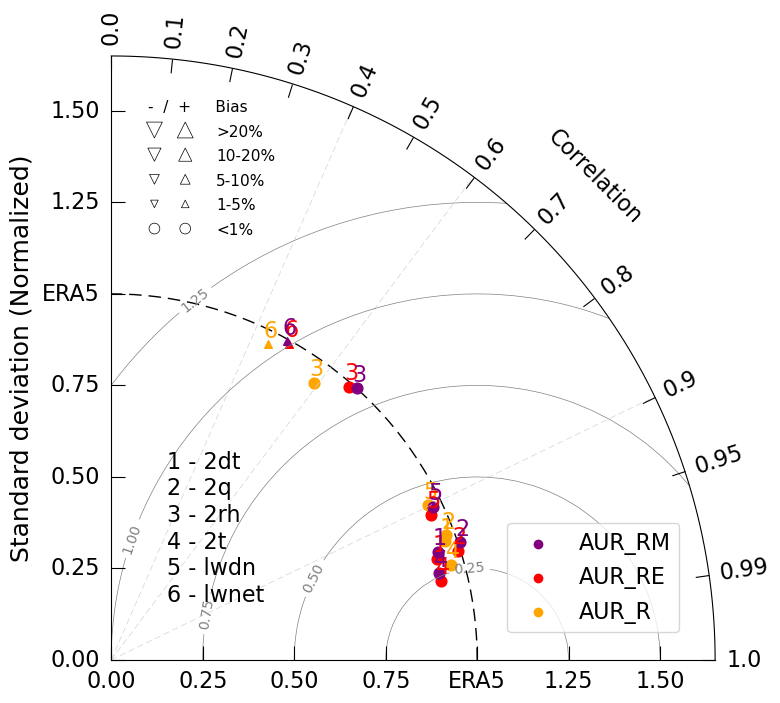

In [16]:
week = 4
var_list = ['2dt', '2q', '2rh', '2t', 'lwdn', 'lwnet']
for mm in [1,]: #ds_out.month.values:
    # Create figure and TaylorDiagram instance
    fig = plt.figure(figsize=(8, 8))
    taylor = gv.TaylorDiagram(fig=fig, label='ERA5')
    
    # Draw diagonal dashed lines from origin to correlation values
    # Also enforces proper X-Y ratio
    taylor.add_corr_grid(np.array([0.4, 0.6, 0.9]))
    
    # Add AUR_R
    taylor.add_model_set(
        ds_out.sel(month=mm,week=week,model="AUR_R",variable=var_list).std_mod_normalized.values,
        ds_out.sel(month=mm,week=week,model="AUR_R",variable=var_list).corr.values,
        percent_bias_on=True,
        bias_array=ds_out.sel(month=mm,week=week,model="AUR_R",variable=var_list).crmsd_normalized.values,
        color='orange',
        label='AUR_R',
        fontsize=16)
    
    # Add AUR_RE
    taylor.add_model_set(
        ds_out.sel(month=mm,week=week,model="AUR_RE",variable=var_list).std_mod_normalized.values,
        ds_out.sel(month=mm,week=week,model="AUR_RE",variable=var_list).corr.values,
        percent_bias_on=True,
        bias_array=ds_out.sel(month=mm,week=week,model="AUR_RE",variable=var_list).crmsd_normalized.values,
        color='red',
        label='AUR_RE',
        fontsize=16)
    
    # Add AUR_RM
    taylor.add_model_set(
        ds_out.sel(month=mm,week=week,model="AUR_RM",variable=var_list).std_mod_normalized.values,
        ds_out.sel(month=mm,week=week,model="AUR_RM",variable=var_list).corr.values,
        percent_bias_on=True,
        bias_array=ds_out.sel(month=mm,week=week,model="AUR_RM",variable=var_list).crmsd_normalized.values,
        color='purple',
        label='AUR_RM',
        fontsize=16)
    
    # Add model name
    taylor.add_model_name(ds_out.sel(variable=var_list).variable.values, x_loc=0.1, y_loc=0.35, fontsize=16)
    
    # Add figure legend
    taylor.add_legend(xloc=0.95, yloc=0.25, fontsize=16, fancybox=True)
    
    # Add bias legend
    taylor.add_bias_legend()
    
    # Add constant centered RMS difference contours.
    cs = taylor.add_contours(levels=np.arange(0, 1.4, 0.25), colors='grey', linewidths=0.5)
    taylor.ax.clabel(cs, inline=True, fontsize=10)
    taylor._ax.axis["top"].label.set_size(16)
    taylor._ax.axis["left"].label.set_size(16)
    taylor._ax.axis["bottom"].label.set_size(16)

fig.savefig(f"Fig_Taylor_w{week}.png", dpi=300, bbox_inches='tight')

In [4]:
week = 3

#NUM_COLORS = ds_out.variable.shape[0]
#cm = plt.get_cmap('gist_rainbow')
#colors = [cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)]
#print(colors)
#cmap = plt.get_cmap('inferno')
#color_array = cmap(np.linspace(0, 1, ds_out.variable.shape[0]))
#print(color_array)

for mm in ds_out.month.values:
    # Create figure and TaylorDiagram instance
    fig = plt.figure(figsize=(8, 8))
    taylor = gv.TaylorDiagram(fig=fig, label='ERA5')

    # Draw diagonal dashed lines from origin to correlation values
    # Also enforces proper X-Y ratio
    taylor.add_corr_grid(np.array([0.6, 0.9]))

    # Add AUR_R
    i = 0
    for var in ds_out.variable.values:
        taylor.add_model_set(
            ds_out.sel(month=mm,week=week,variable=var).std_mod_normalized.values,
            ds_out.sel(month=mm,week=week,variable=var).corr.values,
            percent_bias_on=True,
            color=color_array[i],
            bias_array=ds_out.sel(month=mm,week=week,variable=var).crmsd_normalized.values,
            label=var,
            fontsize=12)
        i=i+1

    # Add model name
    taylor.add_model_name(ds_out.model.values, x_loc=0.05, y_loc=0.5, fontsize=12)

    # Add figure legend
    taylor.add_legend(fontsize=16)

    # Add bias legend
    taylor.add_bias_legend()

    # Add constant centered RMS difference contours.
    taylor.add_contours(levels=np.arange(0, 1.1, 0.25),
                     colors='lightgrey',
                     linewidths=0.5);

NameError: name 'ds_out' is not defined

In [ ]:
fig = plt.figure(figsize=(8, 8))
taylor = gv.TaylorDiagram(fig=fig, label='ERA5')

# Draw diagonal dashed lines from origin to correlation values
# Also enforces proper X-Y ratio
taylor.add_corr_grid(np.array([0.6, 0.9]))

var = '2rh'
month = 1
week = [0, 2, 4]
model = 'AUR_R'
taylor.add_model_set(
    ds_out.sel(month=month,week=week,model=model,variable=var).std_mod_normalized.values,
    ds_out.sel(month=month,week=week,model=model,variable=var).corr.values,
    percent_bias_on=True,
    color="orange",
    bias_array=ds_out.sel(month=month,week=week,model=model,variable=var).crmsd_normalized.values,
    label=model,
    fontsize=12)

model = 'AUR_RE'
taylor.add_model_set(
    ds_out.sel(month=month,week=week,model=model,variable=var).std_mod_normalized.values,
    ds_out.sel(month=month,week=week,model=model,variable=var).corr.values,
    percent_bias_on=True,
    color="red",
    bias_array=ds_out.sel(month=month,week=week,model=model,variable=var).crmsd_normalized.values,
    label=model,
    fontsize=12)

model = 'AUR_RM'
taylor.add_model_set(
    ds_out.sel(month=month,week=week,model=model,variable=var).std_mod_normalized.values,
    ds_out.sel(month=month,week=week,model=model,variable=var).corr.values,
    percent_bias_on=True,
    color="purple",
    bias_array=ds_out.sel(month=month,week=week,model=model,variable=var).crmsd_normalized.values,
    label=model,
    fontsize=12)
    
# Add model name
taylor.add_model_name([f"{str(x+1)}w" for x in ds_out.sel(week=week).week.values], x_loc=0.05, y_loc=0.5, fontsize=12)
    
# Add figure legend
taylor.add_legend(fontsize=16)
    
# Add bias legend
taylor.add_bias_legend()
    
# Add constant centered RMS difference contours.
taylor.add_contours(levels=np.arange(0, 1.1, 0.25),
                     colors='lightgrey',
                     linewidths=0.5);
print(os.__file__)